# Charging Port Demand and Adoption Scenarios

## tl;dr

This notebook estimates public Level 2 and DC fast-charging port requirements for the seven-county Northeast Georgia study area. It compares three EV-adoption scenarios with the existing public charging inventory and produces county-level infrastructure gaps.

The results are **planning estimates**, not electrical-engineering designs. Final installations require parcel, ownership, zoning, utility-capacity, demand-charge, and field verification.

## Context & Methods

The model answers:

> How many public Level 2 and DC fast-charging ports may be needed under different EV-adoption scenarios, and where are the largest county-level shortfalls?

### Key Assumptions

- `vehicle_households` is used as a conservative proxy for the pool of EV-owning households.
- EV adoption scenarios are **5% (near-term), 12% (moderate), and 20% (high)** of vehicle-owning households.
- Public-port benchmark ratios come from NREL's *2030 National Charging Network*: 1,067,000 public Level 2 and 182,000 DC fast ports supporting 33 million EVs.
- Benchmark ratios therefore equal **32.33 Level 2** and **5.52 DC fast ports per 1,000 EVs**.
- Level 2 demand is adjusted by each county's population-weighted public-access need. The multiplier is bounded from 0.85 to 1.25.
- DC fast demand is adjusted by the county's population-weighted corridor-demand score. The multiplier is bounded from 0.90 to 1.20.
- Existing station records are deduplicated by AFDC station `ID` before ports are summed.
- Required ports are rounded upward; additional ports cannot be negative.

Sources:

- NREL, *The 2030 National Charging Network*, NREL/TP-5400-85654.
- DOE Alternative Fuels Data Center station inventory downloaded earlier in this project.
- U.S. Census Bureau 2020–2024 ACS 5-year estimates.

## Data

### 1. Setup and parameters

In [1]:
from pathlib import Path
import math

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability")
SPATIAL_DIR = PROJECT_ROOT / "outputs" / "spatial"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SCENARIOS = {
    "Near-term (5%)": 0.05,
    "Moderate (12%)": 0.12,
    "High (20%)": 0.20,
}

NREL_SUPPORTING_EVS = 33_000_000
NREL_PUBLIC_L2_PORTS = 1_067_000
NREL_DC_FAST_PORTS = 182_000
L2_PORTS_PER_1000_EVS = NREL_PUBLIC_L2_PORTS / NREL_SUPPORTING_EVS * 1000
DC_PORTS_PER_1000_EVS = NREL_DC_FAST_PORTS / NREL_SUPPORTING_EVS * 1000

print(f"Level 2 benchmark: {L2_PORTS_PER_1000_EVS:.2f} ports per 1,000 EVs")
print(f"DC fast benchmark: {DC_PORTS_PER_1000_EVS:.2f} ports per 1,000 EVs")

Level 2 benchmark: 32.33 ports per 1,000 EVs
DC fast benchmark: 5.52 ports per 1,000 EVs


### 2. Load and validate source data

In [2]:
acs = gpd.read_file(SPATIAL_DIR / "acs_ev_demand_block_groups.gpkg")
corridor = gpd.read_file(SPATIAL_DIR / "dc_fast_corridor_demand.gpkg")
stations = gpd.read_file(SPATIAL_DIR / "existing_ev_charging_units.gpkg")

assert acs["GEOID"].is_unique
assert corridor["GEOID"].is_unique
assert set(acs["GEOID"]) == set(corridor["GEOID"])
assert acs["county_name"].notna().all()

station_count_before = len(stations)
stations = stations.drop_duplicates(subset="ID").copy()
assert stations["ID"].is_unique

for field in ["EV Level2 EVSE Num", "EV DC Fast Count"]:
    stations[field] = pd.to_numeric(stations[field], errors="coerce").fillna(0)

print(f"ACS block groups: {len(acs):,}")
print(f"Corridor block groups: {len(corridor):,}")
print(f"Charging-unit rows: {station_count_before:,}")
print(f"Unique AFDC stations after ID deduplication: {len(stations):,}")

ACS block groups: 926
Corridor block groups: 926
Charging-unit rows: 862
Unique AFDC stations after ID deduplication: 272


### 3. Create county planning inputs

In [3]:
def weighted_mean(values, weights):
    valid = values.notna() & weights.notna() & (weights >= 0)
    if not valid.any() or weights.loc[valid].sum() == 0:
        return np.nan
    return np.average(values.loc[valid], weights=weights.loc[valid])

county_rows = []
for county, group in acs.groupby("county_name"):
    corridor_group = corridor.loc[corridor["county_name"] == county]
    county_rows.append({
        "county_name": county,
        "population": int(group["population"].sum()),
        "households": int(group["households"].sum()),
        "vehicle_households": int(group["vehicle_households"].sum()),
        "public_access_need_index": weighted_mean(
            group["public_access_need_index"], group["population"]
        ),
        "dc_corridor_score": weighted_mean(
            corridor_group["dc_corridor_score"], corridor_group["population"]
        ),
    })

county_inputs = pd.DataFrame(county_rows)

existing = (
    stations.groupby("County", as_index=False)
    .agg(
        existing_stations=("ID", "nunique"),
        existing_l2_ports=("EV Level2 EVSE Num", "sum"),
        existing_dc_fast_ports=("EV DC Fast Count", "sum"),
    )
    .rename(columns={"County": "county_name"})
)

county_inputs = county_inputs.merge(
    existing, on="county_name", how="left", validate="one_to_one"
)
fill_columns = ["existing_stations", "existing_l2_ports", "existing_dc_fast_ports"]
county_inputs[fill_columns] = county_inputs[fill_columns].fillna(0)

county_inputs["l2_access_multiplier"] = (
    0.85 + 0.40 * county_inputs["public_access_need_index"] / 100
).clip(0.85, 1.25)
county_inputs["dc_corridor_multiplier"] = (
    0.90 + 0.30 * county_inputs["dc_corridor_score"] / 100
).clip(0.90, 1.20)

county_inputs.sort_values("county_name")

,county_name,population,households,vehicle_households,public_access_need_index,dc_corridor_score,existing_stations,existing_l2_ports,existing_dc_fast_ports,l2_access_multiplier,dc_corridor_multiplier
0,Barrow,89886,30789,83841,39.357678,31.648043,13,29.0,9.0,1.007431,0.994944
1,Clarke,129609,54454,150628,70.365417,29.094573,36,69.0,32.0,1.131462,0.987284
2,Gwinnett,979864,327043,885128,53.033031,58.945126,175,385.0,174.0,1.062132,1.076835
3,Hall,212705,73551,174856,46.791255,47.615417,30,65.0,46.0,1.037165,1.042846
4,Jackson,84757,28402,83368,35.514827,45.523865,5,8.0,5.0,0.992059,1.036572
5,Oconee,43551,14994,35733,36.324729,26.992303,8,16.0,10.0,0.995299,0.980977
6,Walton,103313,35755,96922,34.040004,29.300722,5,8.0,6.0,0.986160,0.987902


## Results

### 4. Calculate scenario requirements and gaps

In [4]:
scenario_frames = []

for scenario_name, adoption_rate in SCENARIOS.items():
    modeled = county_inputs.copy()
    modeled["scenario"] = scenario_name
    modeled["adoption_rate"] = adoption_rate
    modeled["projected_evs"] = np.ceil(
        modeled["vehicle_households"] * adoption_rate
    ).astype(int)
    modeled["required_l2_ports"] = np.ceil(
        modeled["projected_evs"]
        * L2_PORTS_PER_1000_EVS / 1000
        * modeled["l2_access_multiplier"]
    ).astype(int)
    modeled["required_dc_fast_ports"] = np.ceil(
        modeled["projected_evs"]
        * DC_PORTS_PER_1000_EVS / 1000
        * modeled["dc_corridor_multiplier"]
    ).astype(int)
    modeled["additional_l2_ports"] = (
        modeled["required_l2_ports"] - modeled["existing_l2_ports"]
    ).clip(lower=0).astype(int)
    modeled["additional_dc_fast_ports"] = (
        modeled["required_dc_fast_ports"] - modeled["existing_dc_fast_ports"]
    ).clip(lower=0).astype(int)
    scenario_frames.append(modeled)

demand = pd.concat(scenario_frames, ignore_index=True)
demand = demand.sort_values(["adoption_rate", "county_name"]).reset_index(drop=True)

scenario_totals = (
    demand.groupby(["scenario", "adoption_rate"], as_index=False)
    .agg(
        projected_evs=("projected_evs", "sum"),
        required_l2_ports=("required_l2_ports", "sum"),
        existing_l2_ports=("existing_l2_ports", "sum"),
        additional_l2_ports=("additional_l2_ports", "sum"),
        required_dc_fast_ports=("required_dc_fast_ports", "sum"),
        existing_dc_fast_ports=("existing_dc_fast_ports", "sum"),
        additional_dc_fast_ports=("additional_dc_fast_ports", "sum"),
    )
    .sort_values("adoption_rate")
)

scenario_totals

,scenario,adoption_rate,projected_evs,required_l2_ports,existing_l2_ports,additional_l2_ports,required_dc_fast_ports,existing_dc_fast_ports,additional_dc_fast_ports
2,Near-term (5%),0.05,75528,2574,580.0,1994,441,282.0,159
1,Moderate (12%),0.12,181260,6172,580.0,5592,1053,282.0,771
0,High (20%),0.20,302099,10287,580.0,9707,1753,282.0,1471


### 5. Review the moderate-adoption county ranking

In [5]:
moderate = demand.loc[demand["scenario"] == "Moderate (12%)"].copy()
moderate["combined_additional_ports"] = (
    moderate["additional_l2_ports"] + moderate["additional_dc_fast_ports"]
)
moderate = moderate.sort_values(
    ["combined_additional_ports", "county_name"], ascending=[False, True]
)

moderate[[
    "county_name",
    "projected_evs",
    "existing_l2_ports",
    "required_l2_ports",
    "additional_l2_ports",
    "existing_dc_fast_ports",
    "required_dc_fast_ports",
    "additional_dc_fast_ports",
]]

,county_name,projected_evs,existing_l2_ports,required_l2_ports,additional_l2_ports,existing_dc_fast_ports,required_dc_fast_ports,additional_dc_fast_ports
9,Gwinnett,106216,385.0,3648,3263,174.0,631,457
10,Hall,20983,65.0,704,639,46.0,121,75
8,Clarke,18076,69.0,662,593,32.0,99,67
13,Walton,11631,8.0,371,363,6.0,64,58
11,Jackson,10005,8.0,321,313,5.0,58,53
7,Barrow,10061,29.0,328,299,9.0,56,47
12,Oconee,4288,16.0,138,122,10.0,24,14


### 6. Visualize scenario port gaps

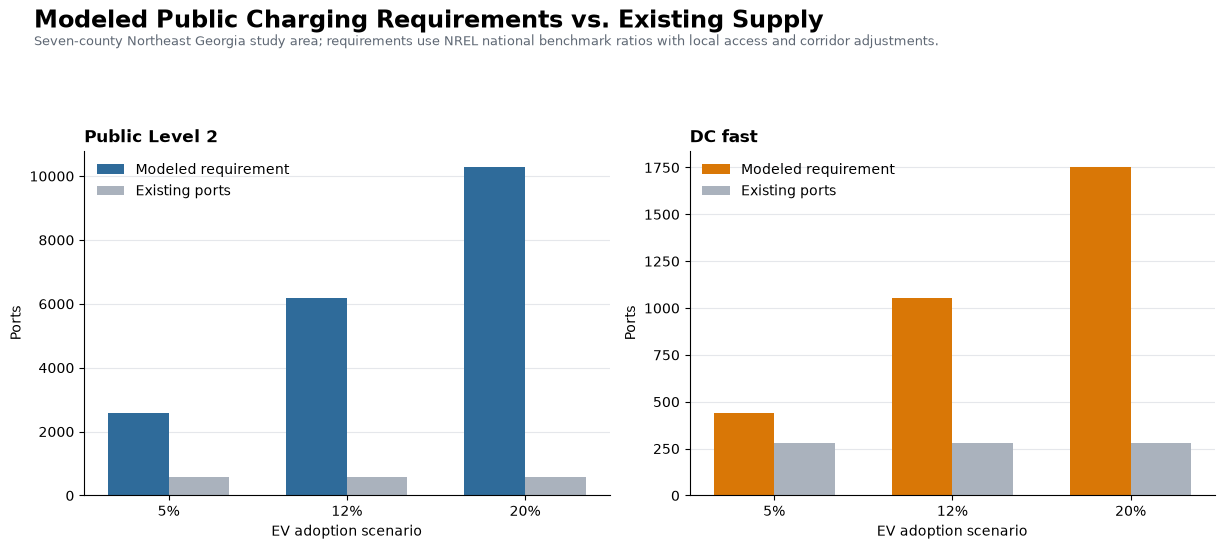

Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\figures\charging_port_demand_scenarios.png


In [6]:
plot_data = scenario_totals.copy()
x = np.arange(len(plot_data))
width = 0.34

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor="white")

for ax, required_col, existing_col, title, color in [
    (axes[0], "required_l2_ports", "existing_l2_ports", "Public Level 2", "#2F6B9A"),
    (axes[1], "required_dc_fast_ports", "existing_dc_fast_ports", "DC fast", "#D97706"),
]:
    required = plot_data[required_col].to_numpy()
    existing_values = plot_data[existing_col].to_numpy()
    ax.bar(x - width / 2, required, width, color=color, label="Modeled requirement")
    ax.bar(x + width / 2, existing_values, width, color="#AAB2BD", label="Existing ports")
    ax.set_title(title, loc="left", weight="bold")
    ax.set_xticks(x, ["5%", "12%", "20%"])
    ax.set_xlabel("EV adoption scenario")
    ax.set_ylabel("Ports")
    ax.grid(axis="y", color="#E5E7EB", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)

fig.suptitle(
    "Modeled Public Charging Requirements vs. Existing Supply",
    x=0.06, y=1.02, ha="left", fontsize=17, weight="bold"
)
fig.text(
    0.06, 0.955,
    "Seven-county Northeast Georgia study area; requirements use NREL national benchmark ratios with local access and corridor adjustments.",
    fontsize=9, color="#5F6874"
)
fig.tight_layout(rect=[0.03, 0.03, 0.98, 0.90])

figure_path = FIGURE_DIR / "charging_port_demand_scenarios.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", figure_path)

### 7. Save planning tables and run QA checks

In [7]:
demand_path = TABLE_DIR / "charging_port_demand_by_county.csv"
totals_path = TABLE_DIR / "charging_port_demand_scenario_totals.csv"
demand.to_csv(demand_path, index=False)
scenario_totals.to_csv(totals_path, index=False)

assert len(demand) == county_inputs["county_name"].nunique() * len(SCENARIOS)
assert demand[["projected_evs", "required_l2_ports", "required_dc_fast_ports"]].notna().all().all()
assert (demand[["additional_l2_ports", "additional_dc_fast_ports"]] >= 0).all().all()
assert demand.groupby("county_name")["projected_evs"].apply(
    lambda values: values.is_monotonic_increasing
).all()
assert demand.groupby("county_name")["required_l2_ports"].apply(
    lambda values: values.is_monotonic_increasing
).all()
assert demand.groupby("county_name")["required_dc_fast_ports"].apply(
    lambda values: values.is_monotonic_increasing
).all()
assert math.isclose(
    county_inputs["existing_l2_ports"].sum(),
    stations["EV Level2 EVSE Num"].sum()
)
assert math.isclose(
    county_inputs["existing_dc_fast_ports"].sum(),
    stations["EV DC Fast Count"].sum()
)
assert demand_path.exists() and totals_path.exists() and figure_path.exists()

print("All grain, deduplication, monotonicity, nonnegative-gap, reconciliation, and output checks passed.")
print("Saved:", demand_path)
print("Saved:", totals_path)

All grain, deduplication, monotonicity, nonnegative-gap, reconciliation, and output checks passed.
Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\tables\charging_port_demand_by_county.csv
Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\tables\charging_port_demand_scenario_totals.csv


## Takeaways

The moderate scenario is the primary planning case for the next notebook. County-level additional-port estimates will be combined with:

- environmental eligibility,
- Level 2 destination suitability,
- community charging gaps,
- DC fast corridor demand,
- existing station spacing, and
- practical minimum site sizes.

Notebook 10 will allocate the modeled demand to ranked candidate locations and recommend charging level, power category, connector mix, initial ports, and expansion capacity.

### Limitations

- National benchmark ratios are not a substitute for an EVI-Pro/EVI-X regional simulation.
- Vehicle-owning households are a proxy rather than an observed EV-registration forecast.
- Existing AFDC counts reflect the downloaded snapshot and may not capture projects under construction.
- County totals do not represent electrical capacity at any specific parcel.
- Corridor demand includes through-travel signals, but this notebook does not run a vehicle-flow or charger-queue simulation.